# 05 — Phase-2 Bayesian Fit

Fits the Phase-2 PyMC model (glycogen-water as a latent random walk plus per-protocol observation noise) and saves the trace to `notebooks/predictions/posterior.nc` for consumption by notebook 04's posterior-track section.

Scope (per `foodlog-adu`):
- `sigma_glycogen` — day-to-day glycogen-water innovation SD
- `sigma_obs_controlled` / `sigma_obs_uncontrolled` — per-protocol observation noise
- Latent `g_t` — GaussianRandomWalk
- Hall trajectory at population defaults (intake_bias / RMR_scale fitting deferred to a future Phase-2.1 bead)

Real-data caveat: as of 2026-05-21 we have only ~12 weigh-ins (post-exclusion), so the posterior will be wide. Synthetic-data parameter recovery passes in tests/body_sim/test_bayesian.py.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from body_sim.config import DEFAULT_PROFILE
from body_sim import bayesian, bayesian_predict

df = pd.read_parquet(REPO_ROOT / 'notebooks' / 'predictions' / 'daily_rollup.parquet')
print(f'n_days={len(df)}, n_obs={df["weight_kg"].notna().sum()}')
df.tail()

n_days=36, n_obs=8


,intake_kcal,protein_g,carb_g,fat_g,sodium_mg,meal_types_logged,intake_coverage,intake_logged,steps,active_kcal_fitbit,...,keytel_baseline_bpm,weight_kg,bf_pct,n_weighins,weigh_in_protocol_controlled,rhr_bpm,sleep_total_h_prev_night,workout_kcal,workout_min,reference_weight_kg
date,,,,,,,,,,,,,,,,,,,,,
2026-05-17,1976.0,88.25,233.5,79.0,0.0,"dinner,lunch,snack",0.666667,False,4793.0,2804.874058,...,78.4,82.200,20.4,2,False,60.0,NaN,0.0,0,82.200
2026-05-18,2007.0,97.00,242.0,78.0,0.0,"breakfast,dinner,lunch",1.000000,True,5176.0,2311.198610,...,65.0,NaN,NaN,0,False,60.0,7.450000,0.0,0,82.200
2026-05-19,2139.0,101.80,225.9,90.8,0.0,"breakfast,dinner,lunch,snack",1.000000,True,8445.0,2673.711612,...,56.8,NaN,NaN,0,False,58.0,5.683333,183.0,26,82.200
2026-05-20,1865.0,92.00,148.0,97.0,0.0,"breakfast,dinner,lunch",1.000000,True,4921.0,2236.981289,...,63.4,83.775,21.1,4,False,58.0,8.283333,0.0,0,83.775
2026-05-21,1492.0,66.00,199.6,55.0,0.0,"dinner,lunch,snack",0.666667,False,NaN,NaN,...,NaN,NaN,NaN,0,False,58.0,NaN,0.0,0,83.775


In [2]:
idata = bayesian.fit(df, profile=DEFAULT_PROFILE, draws=1000, tune=1000, chains=2, seed=42)
idata.to_netcdf(REPO_ROOT / 'notebooks' / 'predictions' / 'posterior.nc')

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [sigma_glycogen, sigma_obs_controlled, sigma_obs_uncontrolled, g]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 3 seconds.


There were 12 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Diagnostics

`r_hat` should be ≤ 1.01 and `ess_bulk` ≥ 400 per chain for each parameter. Wider HDIs at low data volume are expected and acceptable.

In [3]:
az.summary(idata, var_names=['sigma_glycogen', 'sigma_obs_controlled', 'sigma_obs_uncontrolled'])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
sigma_glycogen,0.39,0.15,0.19,0.65,77,59,1.04,0.014,0.015
sigma_obs_controlled,0.24,0.17,0.025,0.55,621,881,1.01,0.0071,0.0056
sigma_obs_uncontrolled,0.51,0.26,0.13,0.97,226,212,1.01,0.016,0.014


## Posterior predictive vs. observed

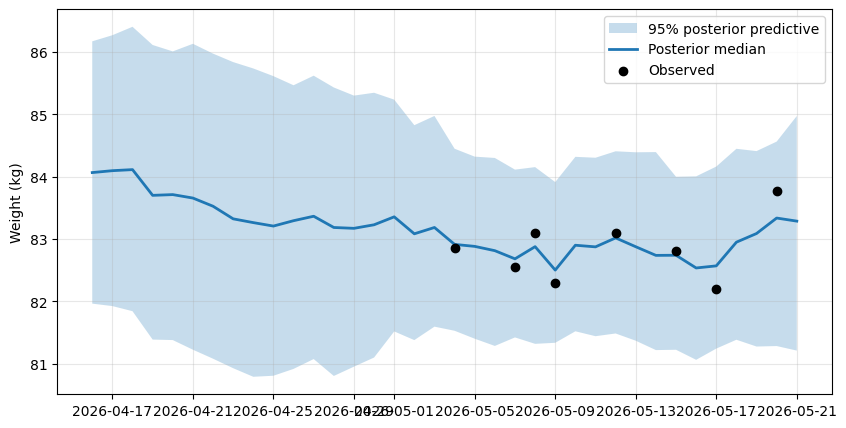

In [4]:
band = bayesian_predict.posterior_predictive_band(idata, df, profile=DEFAULT_PROFILE)
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(df.index, band['lo'], band['hi'], alpha=0.25, label='95% posterior predictive')
ax.plot(df.index, band['median'], linewidth=2, label='Posterior median')
obs = df.dropna(subset=['weight_kg'])
ax.scatter(obs.index, obs['weight_kg'], color='black', zorder=5, label='Observed')
ax.set_ylabel('Weight (kg)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()